In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [ ]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 15)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

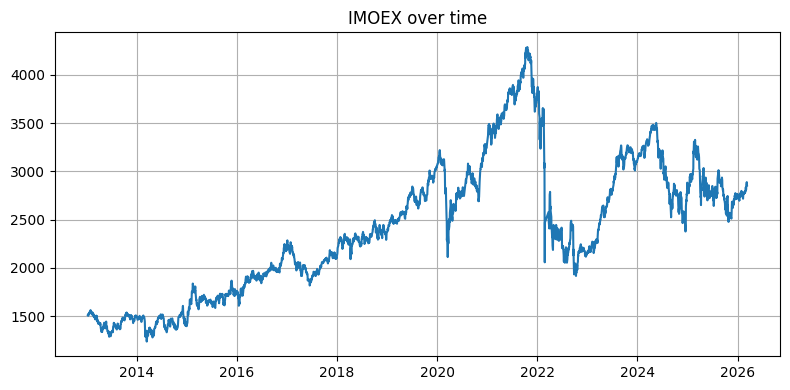

In [2]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [3]:
from src.get_features import add_log_returns, add_volatility

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])

Model is not converging.  Current: 82512.65363733437 is not greater than 82512.90533804623. Delta is -0.25170071185857523
Model is not converging.  Current: 83998.3113286468 is not greater than 83998.31944693207. Delta is -0.008118285273667425
Model is not converging.  Current: 83832.51238299964 is not greater than 83832.71820275798. Delta is -0.20581975833920296
Model is not converging.  Current: 83712.96819664906 is not greater than 83746.65615430787. Delta is -33.687957658810774
Model is not converging.  Current: 82522.86743170628 is not greater than 82579.55755658049. Delta is -56.69012487420696
Model is not converging.  Current: 83660.18731261778 is not greater than 83679.89207721947. Delta is -19.704764601687202
Model is not converging.  Current: 84879.66252527665 is not greater than 84896.63931266176. Delta is -16.976787385108764
Model is not converging.  Current: 85276.0789940753 is not greater than 85428.59913294521. Delta is -152.52013886990608
Model is not converging.  Curre

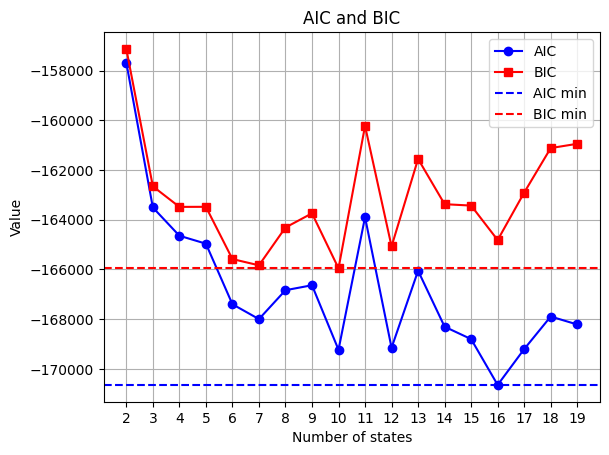

In [4]:
from src.train_hmm import train_hmm
features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]

candles = candles.dropna()
X = candles[features].values

bics = []
aics = []
ks = range(2, 20)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

min_aic = min(aics)
min_bic = min(bics)
plt.axhline(min_aic, linestyle='--', label='AIC min', color='blue')
plt.axhline(min_bic, linestyle='--', label='BIC min', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [5]:
model = train_hmm(X, n_states=3, n_iter=5000)

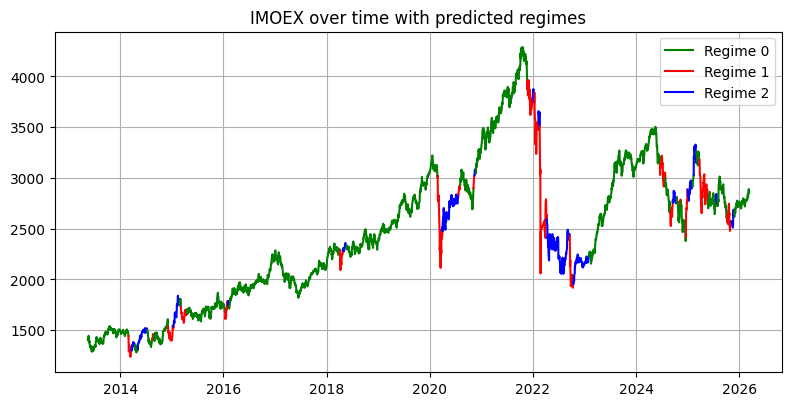

In [6]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [10]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})

print(statistics)

       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.005612  0.022723     0.007986  0.003032  1779
1          -0.017038  0.093090     0.027970  0.027538   261
2          -0.000533  0.036995     0.012135  0.005123  1180


[[9.93673014e-001 1.12586297e-003 5.20112256e-003]
 [2.71283803e-248 9.76951293e-001 2.30487066e-002]
 [1.02908616e-002 3.38327190e-003 9.86325867e-001]]


Text(50.722222222222214, 0.5, 'from')

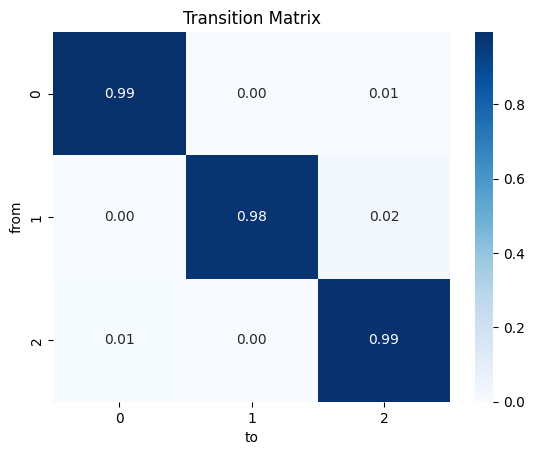

In [11]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
print(model.transmat_)
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")

In [7]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": np.round(expected_duration, 2)
})
print(df)

   Stay Probability  Expected regime duration (days)
0          0.992062                           125.97
1          0.940528                            16.81
2          0.965221                            28.75


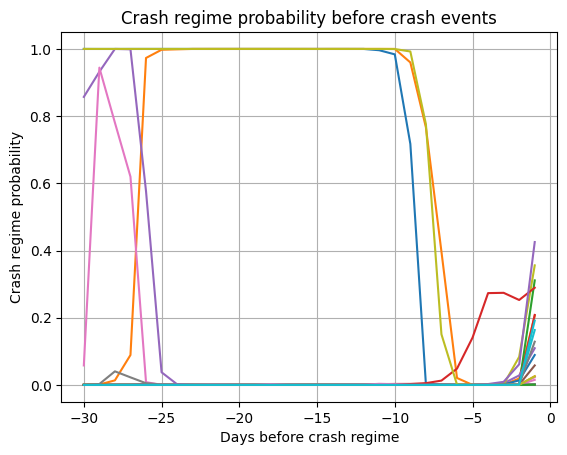

In [31]:
crash_regime = 1
probs = model.predict_proba(X)
crash_prob = probs[:, crash_regime]
candles["crash_prob"] = crash_prob

regimes = model.predict(X)

crash_starts = []
for i in range(1, len(regimes)):
    if regimes[i] == 1 and regimes[i-1] != 1:
        crash_starts.append(i)

window = 30
for index in crash_starts:
    start = max(0, index-window)
    end = index
    
    plt.plot(range(-(end-start), 0), crash_prob[start:end])

plt.xlabel("Days before crash regime")
plt.ylabel("Crash regime probability")
plt.title("Crash regime probability before crash events")
plt.grid()

plt.show()